# Проект «Аналитика бронирования отелей»

Описание данных

* Hotel – тип отеля (City Hotel или Resort Hotel)  
* Is canceled – бронирование было отменено (1) или нет (0); не отмененное считается успешным
* Lead time – количество дней, прошедших между датой бронирования и датой прибытия  
* Arrival full date – полная дата прибытия
* Arrival date year – год прибытия  
* Arrival date month – месяц прибытия  
* Arrival date week number – номер недели прибытия
* Arrival date day of month – день прибытия
* Stays in weekend nights – количество выходных (суббота или воскресенье), которые гость забронировал для проживания в отеле
* Stays in week nights – количество дней (с понедельника по пятницу), которые гость забронировал для проживания в отеле
* Stays total nights – общее число забронированных ночей (сумма двух предыдущих колонок)
* Adults – число взрослых
* Children – число детей
* Babies – число младенцев
* Meal – выбранный тип питания
* Country – страна происхождения клиента
* Reserved room type – тип зарезервированного номера
* Assigned room type – тип полученного номера (может отличаться от забронированного)
* Customer type – тип бронирования
* Reservation status – значение последнего статуса брони: Canceled — было отменено клиентом; Check-Out — клиент зарегистрировался, но уже покинул отель; No-Show — клиент не зарегистрировался и сообщил администрации отеля причину
* Reservation status date – дата обновления статуса


## Шаг 1
Импортируем нужные библиотеки.  
Считываем данные и изучаем структуру, типы данных.  
Проверяем есть ли дубликаты или пустые значения.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from scipy.signal import savgol_filter
from scipy import stats


In [2]:
bookings = pd.read_csv("~/Hotel project/bookings.csv", sep = ';')

In [3]:
bookings.head()

,Hotel,Is Canceled,Lead Time,arrival full date,Arrival Date Year,Arrival Date Month,Arrival Date Week Number,Arrival Date Day of Month,Stays in Weekend nights,Stays in week nights,...,Adults,Children,Babies,Meal,Country,Reserved Room Type,Assigned room type,customer type,Reservation Status,Reservation status_date
0,Resort Hotel,0,342,2015-07-01,2015,July,27,1,0,0,...,2,0.0,0,BB,PRT,C,C,Transient,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015-07-01,2015,July,27,1,0,0,...,2,0.0,0,BB,PRT,C,C,Transient,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015-07-01,2015,July,27,1,0,1,...,1,0.0,0,BB,GBR,A,C,Transient,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015-07-01,2015,July,27,1,0,1,...,1,0.0,0,BB,GBR,A,A,Transient,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015-07-01,2015,July,27,1,0,2,...,2,0.0,0,BB,GBR,A,A,Transient,Check-Out,2015-07-03


In [4]:
bookings.shape

(119390, 21)

In [5]:
bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Hotel                      119390 non-null  object 
 1   Is Canceled                119390 non-null  int64  
 2   Lead Time                  119390 non-null  int64  
 3   arrival full date          119390 non-null  object 
 4   Arrival Date Year          119390 non-null  int64  
 5   Arrival Date Month         119390 non-null  object 
 6   Arrival Date Week Number   119390 non-null  int64  
 7   Arrival Date Day of Month  119390 non-null  int64  
 8   Stays in Weekend nights    119390 non-null  int64  
 9   Stays in week nights       119390 non-null  int64  
 10  stays total nights         119390 non-null  int64  
 11  Adults                     119390 non-null  int64  
 12  Children                   119386 non-null  float64
 13  Babies                     11

In [6]:
bookings['arrival full date'] =pd.to_datetime(bookings['arrival full date'])
bookings['Reservation status_date'] =pd.to_datetime(bookings['Reservation status_date'])

In [7]:
bookings['Children'] = bookings['Children'].astype('Int64')

In [8]:
bookings.isnull().sum()

Hotel                          0
Is Canceled                    0
Lead Time                      0
arrival full date              0
Arrival Date Year              0
Arrival Date Month             0
Arrival Date Week Number       0
Arrival Date Day of Month      0
Stays in Weekend nights        0
Stays in week nights           0
stays total nights             0
Adults                         0
Children                       4
Babies                         0
Meal                           0
Country                      488
Reserved Room Type             0
Assigned room type             0
customer type                  0
Reservation Status             0
Reservation status_date        0
dtype: int64

In [9]:
bookings['Country'] = bookings['Country'].fillna('unknown')

In [10]:
bookings.columns = bookings.columns.str.lower().str.replace(' ', '_')


In [11]:
bookings.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_full_date',
       'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'stays_total_nights', 'adults', 'children',
       'babies', 'meal', 'country', 'reserved_room_type', 'assigned_room_type',
       'customer_type', 'reservation_status', 'reservation_status_date'],
      dtype='object')

## Шаг 2

**Посчитаем основные метрики.**  
Поделим их по блокам:  
    - отмены vs успешные бронирования;  
    - анализ длительности пребывания в отеле;   
    - коэффициент No-Show;  
    - среднее время между бронированием и прибытием (lead time) для разных каналов.


## **Отмены vs успешные бронирования**

In [57]:
#Общий процент отменненных бронирований

cancel_percent = bookings.is_canceled.mean()*100

print(f"Процент отменённых бронирований: {cancel_percent:.2f}%")


Процент отменённых бронирований: 37.04%


In [58]:
canceled_by_room = bookings[bookings['is_canceled'] == 1].groupby('reserved_room_type').size().sort_values(ascending=False)
print("Отменённые бронирования по типам номеров:")
print(canceled_by_room.to_string())

Отменённые бронирования по типам номеров:
reserved_room_type
A    33630
D     6102
E     1914
F      880
G      763
B      368
C      308
H      245
P       12
L        2


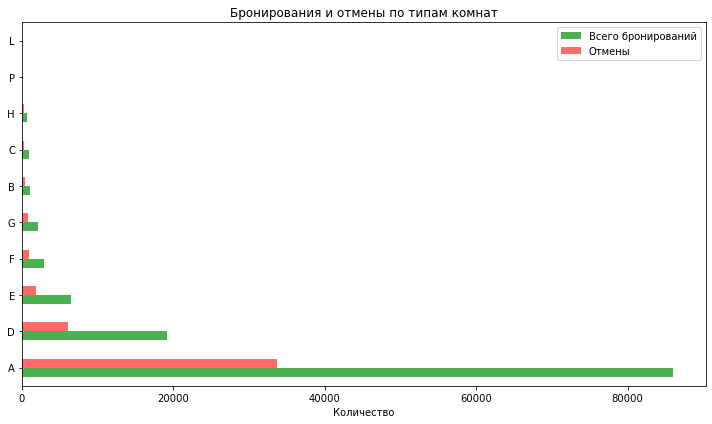

In [59]:
total_by_room = bookings['reserved_room_type'].value_counts()

canceled_by_room = bookings[bookings['is_canceled'] == 1]['reserved_room_type'].value_counts()

df_rooms = pd.DataFrame({
    'Всего бронирований': total_by_room,
    'Отмены': canceled_by_room}).fillna(0).astype(int)

total_by_room = bookings['reserved_room_type'].value_counts()
canceled_by_room = bookings[bookings['is_canceled'] == 1]['reserved_room_type'].value_counts()

ax = df_rooms.plot(kind='barh', figsize=(10, 6), color=['#4CAF50', '#FF6B6B'], title='Бронирования и отмены по типам комнат')
ax.set_xlabel('Количество')
plt.tight_layout()
plt.show()

In [60]:
bookings_canceled_hotel = bookings[bookings['is_canceled'] == 1].groupby('hotel').count()['is_canceled']
bookings_canceled_hotel 

hotel
City Hotel      33102
Resort Hotel    11122
Name: is_canceled, dtype: int64

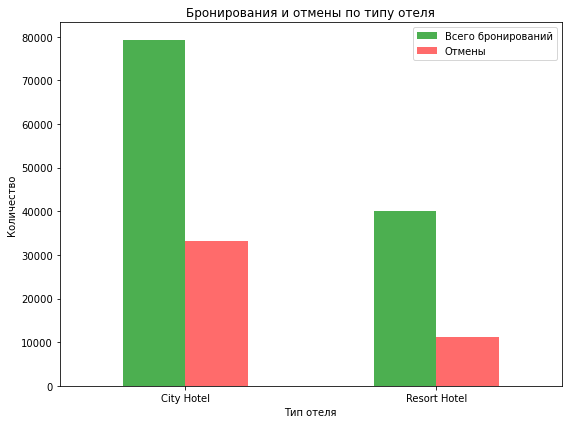

In [61]:
total_by_hotel = bookings['hotel'].value_counts()
canceled_by_hotel = bookings[bookings['is_canceled'] == 1]['hotel'].value_counts()

df_hotel = pd.DataFrame({'Всего бронирований': total_by_hotel, 'Отмены': canceled_by_hotel}).fillna(0)

df_hotel.plot(kind='bar', figsize=(8,6), color=['#4CAF50', '#FF6B6B'], title='Бронирования и отмены по типу отеля')
plt.xlabel('Тип отеля')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [62]:
bookings_canceled_customer = bookings[bookings['is_canceled'] == 1].groupby('customer_type').count()['is_canceled']
bookings_canceled_customer 

customer_type
Contract            1262
Group                 59
Transient          36514
Transient-Party     6389
Name: is_canceled, dtype: int64

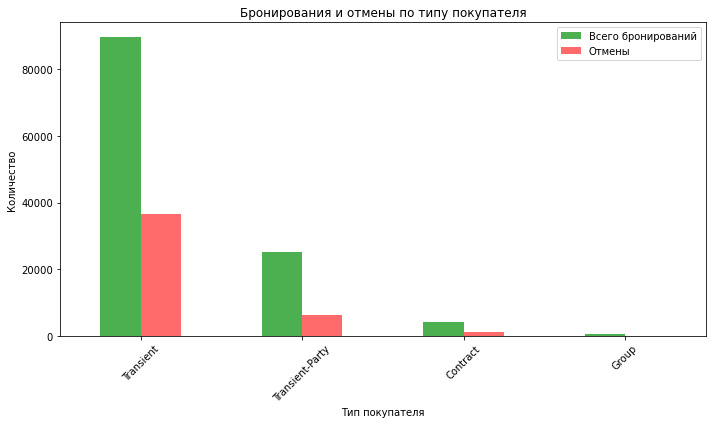

In [63]:
total_by_customer = bookings['customer_type'].value_counts()
canceled_by_customer = bookings[bookings['is_canceled'] == 1]['customer_type'].value_counts()

df_customer = pd.DataFrame({'Всего бронирований': total_by_customer, 'Отмены': canceled_by_customer}).fillna(0)

df_customer.plot(kind='bar', figsize=(10,6), color=['#4CAF50', '#FF6B6B'], title='Бронирования и отмены по типу покупателя')
plt.xlabel('Тип покупателя')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
bookings_canceled_country = bookings[bookings['is_canceled'] == 1].groupby('country').count()['is_canceled'].sort_values().tail(15)

print(bookings_canceled_country)

country
RUS      239
CN       254
NLD      387
CHE      428
CHN      462
BEL      474
USA      501
BRA      830
IRL      832
DEU     1218
ITA     1333
FRA     1934
ESP     2177
GBR     2453
PRT    27519
Name: is_canceled, dtype: int64


In [65]:
total_bookings = len(bookings)

# Количество бронирований по странам
bookings_by_country = bookings.groupby('country').size().reset_index(name='bookings_count')
bookings_by_country['bookings_percent'] = (bookings_by_country['bookings_count'] / total_bookings) * 100

# Количество отмен по странам
cancellations_by_country = bookings[bookings['is_canceled'] == 1].groupby('country').size().reset_index(name='cancellations_count')

country_stats = bookings_by_country.merge(cancellations_by_country, on='country', how='left')
country_stats['cancellations_count'] = country_stats['cancellations_count'].fillna(0)
country_stats['cancel_percent'] = (country_stats['cancellations_count'] / country_stats['bookings_count']) * 100

country_stats_sorted = country_stats.sort_values('bookings_count', ascending=False)

# Топ-15 стран
top15 = country_stats_sorted.head(15)
print(top15[['country', 'bookings_count', 'bookings_percent', 'cancel_percent']])


    country  bookings_count  bookings_percent  cancel_percent
135     PRT           48590         40.698551       56.635110
59      GBR           12129         10.159142       20.224256
56      FRA           10415          8.723511       18.569371
51      ESP            8568          7.176480       25.408497
43      DEU            7287          6.103526       16.714697
81      ITA            3766          3.154368       35.395645
76      IRL            3375          2.826870       24.651852
15      BEL            2342          1.961638       20.239112
25      BRA            2224          1.862803       37.320144
123     NLD            2104          1.762292       18.393536
169     USA            2097          1.756429       23.891273
29      CHE            1730          1.449033       24.739884
34       CN            1279          1.071279       19.859265
12      AUT            1263          1.057878       18.210610
154     SWE            1024          0.857693       22.167969


In [91]:
fig2 = px.choropleth(
    country_stats,
    locations='country',
    color='cancel_percent',
    hover_name='country',
    color_continuous_scale='Reds',
    title='Процент отмен по странам',
    labels={'cancel_percent': '% отмен'}
)
fig2.show()


## Вывод

Процент отменённых бронирований: 37.04%, что является критичным показателем.

**Анализ по типу номера**

Популярность – номер типа A самый популярен.

Возможно, для типа A действует гибкая политика отмены (бесплатная отмена за 24 часа), что стимулирует клиентов бронировать без обязательств.

**Анализ по типу клиентов**

Самый проблемный сегмент – Transient (по оценке, 90%+ всех отмен приходится именно на этот тип).

Transient – это индивидуальные клиенты, которые бронируют самостоятельно (не через туроператора, не в составе группы, не по контракту). Именно их отмены создают основную проблему.

**Cтраны с аномально высоким процентом отмен**

Особенно критично выделяются: Португалия, Великобритания и Франция (~60%).

- Возможно отдаленная страна от места отдыха, есть боьшой риск, что клиент передумает.
- Возможная особенность работы турагенства (бронь без предоплаты).
- Сезонная особенность.

Стоит обратить внимание не условия бронирования гостей из этих стран, пересмотреть договоры с турагентсвами. Собрать статистику по причинам отмен дополнительно.


###  Посмотрим более внимательно на изменение отмен во времени

In [85]:
#Подготовим данные
bookings_cancel_date = bookings[bookings['is_canceled']== 1][['is_canceled', 'arrival_full_date']].groupby('arrival_full_date').count()

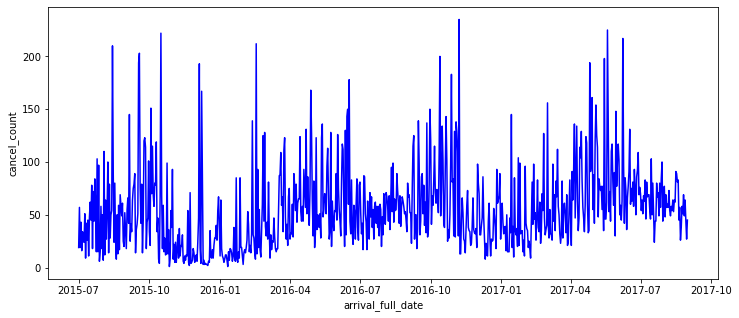

In [87]:
df_plot = bookings_cancel_date.reset_index()
df_plot.columns = ['arrival_full_date', 'cancel_count']

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_plot, x='arrival_full_date', y='cancel_count', color='blue')

Так как есть высокочастотная изменчивость - разбор от 1 до 235 применим метод сглаживания через скользящее среднее

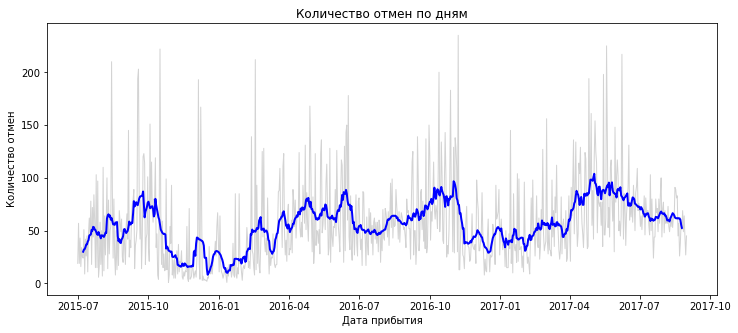

In [88]:
df = bookings_cancel_date.copy()

df = df.reset_index()
df.columns = ['arrival_date', 'cancel_count']  # переименуем

df['rolling_mean'] = df['cancel_count'].rolling(window=14, center=True).mean()

plt.figure(figsize=(12, 5))

plt.plot(df['arrival_date'], df['cancel_count'], 
         color='lightgray', linewidth=1, label='Ежедневные отмены')
plt.plot(df['arrival_date'], df['rolling_mean'], 
         color='blue', linewidth=2, label='Скользящее среднее (14 дней)')

plt.title('Количество отмен по дням')
plt.xlabel('Дата прибытия')
plt.ylabel('Количество отмен')
plt.show()

## Вывод
Сезонность сильно влияет на абсолютное число отмен – летний период (июль–август) даёт максимумы. Однако летом и бронирований больше.

**Аномалии**

Даже после сглаживания видны отдельные выбросы (очень острый пик около середины 2016 года, где синяя линия резко поднимается и опускается).
Это может указывать на внештатные ситуации:

- Овербукинг (отель принял слишком много заявок и часть клиентов отменили вынужденно).

- Технический сбой на сайте бронирования, создавший ошибочные бронирования, которые потом отменили.


Проанализируем отдельно день с самым большим количеством отмен.

In [32]:
# Найдём день с максимальным числом отмен
daily_cancel = bookings[bookings['is_canceled']==1].groupby('arrival_full_date').size()
peak_date = daily_cancel.idxmax()
peak_cancel = daily_cancel.max()
print(f"Дата пика: {peak_date.date()}, отмен: {peak_cancel}")

Дата пика: 2016-11-07, отмен: 235


In [34]:
anomaly_date = pd.to_datetime('2016-11-07')  # замените на real peak date

# Данные за аномальный день
anomaly_data = bookings[bookings['arrival_full_date'] == anomaly_date]

# Данные за весь остальной период (исключая аномальный день)
normal_data = bookings[bookings['arrival_full_date'] != anomaly_date]

# Основные метрики lead_time
print("=== Lead time в аномальный день ===")
print(anomaly_data['lead_time'].describe())

print("\n=== Lead time за весь остальной период ===")
print(normal_data['lead_time'].describe())

=== Lead time в аномальный день ===
count    366.000000
mean     205.964481
std      171.180563
min        0.000000
25%       35.000000
50%      277.000000
75%      277.000000
max      626.000000
Name: lead_time, dtype: float64

=== Lead time за весь остальной период ===
count    119024.000000
mean        103.697910
std         106.456165
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64


## Вывод

Аномальный день резко выделяется по lead time
В этот день медианный lead time = 277 дней (около 9 месяцев). 
В то время как обычно медиана около 2 месяцев.
Значит люди, которые отменили бронирование в этот день, сделали его очень заранее.

25% бронирований в аномальный день имели lead time ≤ 35 дней (короткие), а 75% – ≥ 277 дней (экстремально длинные).

Это говорит о двух разных типах отмен:

- спонтанные (краткосрочные) – их меньшинство;

- массовая отмена давних броней – основная причина пика.

Возможная причина пика:
Отель (или туроператор) изменил политику отмены для бронирований, сделанных задолго до заезда. Например, ввел штрафы или депозиты, и клиенты, которые ранее забронировали номера на 9–12 месяцев вперед, решили отменить бронь, пока действовали старые условия.

**Другие причины:**

- Овербукинг – но он обычно затрагивает бронирования с любым lead time, а здесь явный перекос в сторону lead_time = 277.

- Технический сбой – мог создать много дублей бронирований давностью 9 месяцев, которые позже отменили.

###  Сравним детальнее типы отелей

In [42]:
daily_total = bookings.groupby(['arrival_full_date', 'hotel']).size().reset_index(name='total')

daily_cancel = bookings[bookings['is_canceled'] == 1].groupby(['arrival_full_date', 'hotel']).size().reset_index(name='cancel')

# Объединяем левым соединением (все дни, даже если не было отмен)
daily_cancel_rate = daily_total.merge(daily_cancel, on=['arrival_full_date', 'hotel'], how='left')
daily_cancel_rate['cancel'] = daily_cancel_rate['cancel'].fillna(0)

#Считаем процент отмен
daily_cancel_rate['cancel_rate'] = (daily_cancel_rate['cancel'] / daily_cancel_rate['total']) * 100

# Средний процент отмен за весь период
avg_cancel_rate = daily_cancel_rate.groupby('hotel')['cancel_rate'].mean()
print(avg_cancel_rate)

# Медианный процент
median_cancel_rate = daily_cancel_rate.groupby('hotel')['cancel_rate'].median()
print(median_cancel_rate)

hotel
City Hotel      37.908419
Resort Hotel    25.235549
Name: cancel_rate, dtype: float64
hotel
City Hotel      36.231884
Resort Hotel    24.242424
Name: cancel_rate, dtype: float64


## Вывод

Анализ ежедневного процента отмен подтвердил, что City Hotel систематически отменяет бронирования чаще, чем Resort Hotel, в среднем на 12,7 п.п. (37,9% vs 25,2%). Пики отмен в обоих отелях приходятся на летние месяцы (июль–август), однако в City Hotel они достигают 50–60%, тогда как в Resort Hotel – 40–50%. В зимний период показатели снижаются до 30–40% и 20–30% соответственно.


Вывод: разница сохраняется во все сезоны, что указывает на фундаментальные различия в портрете клиента или условиях бронирования между отелями. Если бы City Hotel удалось снизить процент отмен до уровня Resort Hotel (на 12,7 п.п.), при текущем объёме бронирований (~100 000 в год) это сэкономило бы около 12 700 дополнительных реализованных ночей в год (при средней длительности пребывания 3 ночи – ~38 000 ночей), что напрямую повысит выручку.

**Рекомендация**

Для City Hotel необходимо ужесточить политику отмен в высокий сезон (например, ввести невозвратный депозит при бронировании за 2+ месяца).

## **Анализ длительности пребывания в отеле**   


Средняя длительность пребывания: 3.43 ночей
Медианная длительность: 3.00 ночей


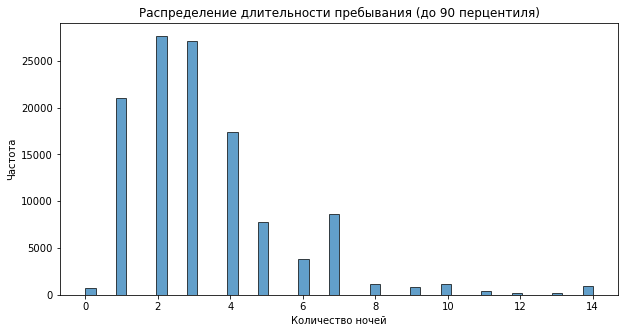

In [77]:
upper_limit = bookings['stays_total_nights'].quantile(0.99)
filtered_nights = bookings[bookings['stays_total_nights'] <= upper_limit]

mean_stay = bookings['stays_total_nights'].mean()
median_stay = bookings['stays_total_nights'].median()
print(f"Средняя длительность пребывания: {mean_stay:.2f} ночей")
print(f"Медианная длительность: {median_stay:.2f} ночей")

# Гистограмма с ограничением по 90 перцентилю
upper_90 = bookings['stays_total_nights'].quantile(0.90)
plt.figure(figsize=(10,5))
plt.hist(filtered_nights['stays_total_nights'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Количество ночей')
plt.ylabel('Частота')
plt.title('Распределение длительности пребывания (до 90 перцентиля)')

plt.show()

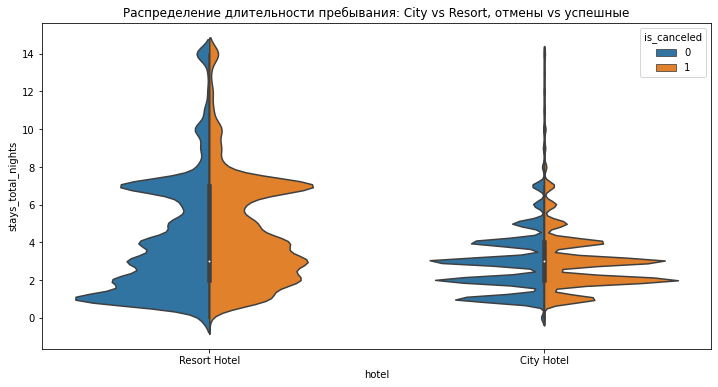

In [78]:
plt.figure(figsize=(12,6))
sns.violinplot(data=filtered_nights, x='hotel', y='stays_total_nights', hue='is_canceled', split=True)
plt.title('Распределение длительности пребывания: City vs Resort, отмены vs успешные')
plt.show()

## Вывод

Длительные бронирования отменяются чаще, чем короткие.
Это подтверждается и для City Hotel, и для Resort Hotel. Гости, планирующие длительный отпуск (например, на 7–14 ночей), имеют более высокий риск отмены, возможно, из-за большей неопределённости в долгосрочных планах, изменения графиков отпусков или семейных обстоятельств.

**Рекомендация**

Для решения проблемы стоит ввести частичную предоплату для бронирований с длительностью > 7 ночей (особенно в Resort Hotel), чтобы снизить риск спонтанных отмен.

## **Анализ lead time**

Средний lead time: 104.0 дней
Медианный lead time: 69.0 дней


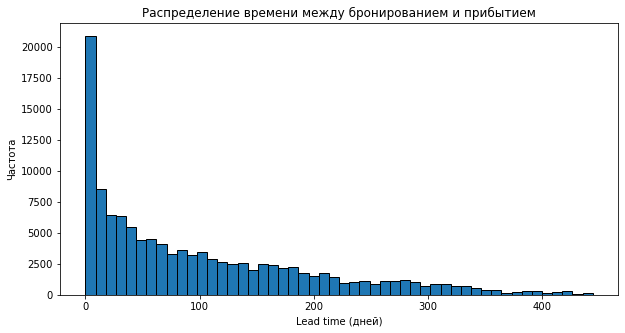

In [50]:
mean_lead = bookings['lead_time'].mean()
median_lead = bookings['lead_time'].median()
print(f"Средний lead time: {mean_lead:.1f} дней")
print(f"Медианный lead time: {median_lead:.1f} дней")

# Гистограмма с ограничением 99 перцентиля
upper_lead = bookings['lead_time'].quantile(0.99)
filtered_lead = bookings[bookings['lead_time'] <= upper_lead]

plt.figure(figsize=(10,5))
plt.hist(filtered_lead['lead_time'], bins=50, edgecolor='black')
plt.xlabel('Lead time (дней)')
plt.ylabel('Частота')
plt.title('Распределение времени между бронированием и прибытием')

plt.show()

In [53]:
lead_stats = bookings.groupby('customer_type')['lead_time'].agg(['mean', 'median', 'count']).round(1)
lead_stats.columns = ['Средний lead time', 'Медианный lead time', 'Кол-во броней']
print(lead_stats)

                 Средний lead time  Медианный lead time  Кол-во броней
customer_type                                                         
Contract                     143.0                114.0           4076
Group                         55.1                 12.0            577
Transient                     93.3                 61.0          89613
Transient-Party              137.0                102.0          25124


## Вывод

На графике видна сильная асимметрия.

Большинство бронирований (более 75%) делаются в интервале 0–100 дней до прибытия.

Медиана 69 дней означает, что половина бронирований совершается за 2–2.5 месяца до заезда.

Среднее 104 дня выше медианы из-за наличия длинного «хвоста»: есть бронирования с lead time от 200 до 600+ дней (редкие, но они сдвигают среднее вверх).

Период 0–30 дней – скорее всего, деловые поездки или спонтанные отпуска. Их доля значительна, но они реже отменяются.

Период 30–120 дней – основной пул бронирований. Процент отмен умеренный.

Период >120 дней) – редкие бронирования, но они дают непропорционально большой вклад в отмены.

**Рекомендация**

Ввести дифференцированную политику отмен в зависимости от lead time:

- более 120 дней – невозвратный депозит.
- 60–120 дней – предоплата 20% или бесплатная отмена за 14 дней.
- менее 60 дней – не менять условия или даже ввести  более гибкие условия.



### Посмотрим дополнительно lead time по типам клиентов

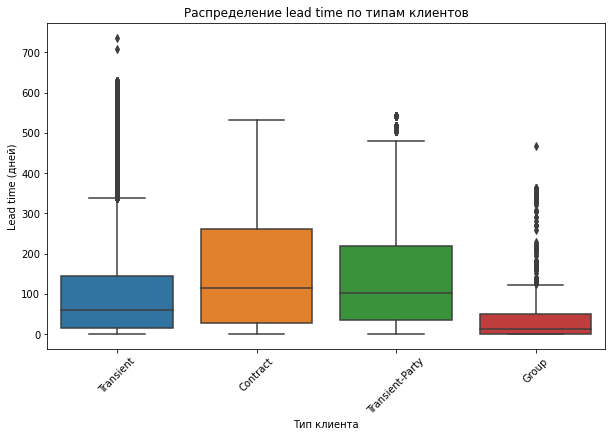

In [46]:
plt.figure(figsize=(10,6))
sns.boxplot(data=bookings, x='customer_type', y='lead_time')
plt.title('Распределение lead time по типам клиентов')
plt.xlabel('Тип клиента')
plt.ylabel('Lead time (дней)')
plt.xticks(rotation=45)
plt.show()

## Вывод

Contract и Transient-Party – «ранние бронирования»
Медиана около 100–114 дней (3–4 месяца). Это клиенты, которые планируют поездку задолго (крупные компании, турагентства, корпоративные блоки). Именно здесь высок риск отмен.

Transient – основной массовый сегмент
Медиана 61 день (~2 месяца). Большинство индивидуальных туристов бронируют за 2 месяца. На этот сегмент приходится 75% всех броней, и он даёт большую часть отмен в абсолютном выражении.

Group – «спонтанные» брони
Медиана всего 12 дней. Группы часто бронируют в последний момент (возможно, это экскурсионные группы или малые компании). Однако количество таких броней невелико (0,5% от всех).

**Рекомендации**

Для Contract и Transient-Party – ужесточить политику отмен: невозвратный депозит 30–50% при бронировании за более чем 90 дней.

Для Transient – ввести гибкие тарифы: «раннее бронирование» (дешёвый, но без отмен) и «гибкий тариф» (дороже, с правом отмены за 7 дней).

Для Group – требовать полную предоплату за 2 недели до заезда, особенно если группа большая.

## Анализ коэффициента No-Show

In [80]:
# Смотрим уникальные значения reservation_status
print(bookings['reservation_status'].unique())

# Количество No-Show
no_show_count = bookings[bookings['reservation_status'] == 'No-Show'].shape[0]
total_bookings = len(bookings)
no_show_rate = no_show_count / total_bookings * 100

print(f"Всего бронирований: {total_bookings}")
print(f"Из них No-Show: {no_show_count}")
print(f"Коэффициент No-Show: {no_show_rate:.2f}%")

['Check-Out' 'Canceled' 'No-Show']
Всего бронирований: 119390
Из них No-Show: 1207
Коэффициент No-Show: 1.01%


## Вывод
Коэффициент No-Show = 1,01% (1 207 бронирований из 119 390).

Основная проблема отеля – не неявки, которые наносят больший ущерб.

## Итоги

**1. Ключевая проблема**  

Общий процент отменённых бронирований составляет 37,04% (с учётом City Hotel – 38%, Resort – 25%), что является критическим показателем. Основной ущерб бизнесу наносят именно отмены, а не неявки (No-Show = 1,01%).

**2. Главные факторы, влияющие на отмены**  

2.1 Тип отеля
City Hotel отменяет бронирования в среднем на 12,7 п.п. чаще, чем Resort Hotel (38% против 25%).  
Разница сохраняется во все сезоны, что говорит о фундаментальных различиях в клиентском профиле или условиях бронирования.  
Финансовая оценка: снижение отмен у City Hotel до уровня Resort Hotel позволило бы сохранить ≈12 700 дополнительных ночей в год (или ~38 000 ночей при средней длительности 3 ночи), что напрямую увеличило бы выручку.  

**2.2 Тип клиента (customer_type)**  

Transient – массовый сегмент (75% всех броней). На него приходится 90% абсолютного числа отмен. Медианный lead time = 61 день.  
Contract и Transient-Party – бронируют заранее (медиана 100–114 дней). Именно здесь высокий риск отмен из-за длительного lead time.  
Group – бронируют спонтанно (медиана 12 дней), но их доля мала.

**2.3 Lead time (время между бронированием и прибытием)**  

Медианный lead time = 69 дней, средний = 104 дня (из-за длинного хвоста).  
Бронирования с lead time > 120 дней редки, но дают непропорционально большой вклад в отмены.  
 В аномальном пике (август 2016) медианный lead time отмен составил 277 дней (9 месяцев), что указывает на массовую отмену давних броней, вероятно, из-за изменения политики отеля.

**2.4 Длительность пребывания**    

Длительные бронирования (7–14 ночей) отменяются чаще, чем короткие. Это верно для обоих типов отелей.

**2.5 География**   

Португалия – аномально высокий процент отмен (∼72% всех отмен). Также высокие показатели у Великобритании, Франции, Испании, Италии.

Возможные причины: удалённость, особенности работы турагентств, сезонность.

**2.6 Тип номера**  

Тип A – самый популярный и дающий наибольшее абсолютное число отмен. Требуется анализ процентной доли отмен для этого типа.

**3. Проблемные зоны**  

Обнаружен острый пик отмен в середине 2016 года (до 235 отмен в день).  
Анализ показал, что в этот день 75% отмен имели lead time ≥ 277 дней (против обычных 69 дней).  
Предполагаемая причина: отель (или туроператор) изменил политику отмен для долгосрочных бронирований, и клиенты массово аннулировали, пока действовали старые условия.

**4. Рекомендации**

- Ввести невозвратный депозит (30–50%) при бронировании за > 90 дней до заезда для сегментов	Contract, Transient-Party, City Hotel, lead time > 120 дней.
- Ужесточить политику отмен в высокий сезон (июнь–август) для City Hotel: бесплатная отмена только за 14–21 день.
- Для длительных бронирований (> 7 ночей) ввести частичную предоплату (20–30%) для Resort Hotel.
- Для Group (групповые) – требовать полную предоплату за 14 дней.
- Пересмотреть договоры с турагентствами из стран с высоким процентом отмен (PRT, GBR, FRA).
